In [30]:
from pathlib import Path

import numpy as np
import pandas as pd

possible_paths = [
    Path("observations-706040.csv/observations-706040.csv"),
    Path("observations-706640.csv"),
]

csv_path = next((p for p in possible_paths if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError("Arquivo observations-698663.csv nao encontrado.")

# Deteccao automatica de delimitador
raw_df = pd.read_csv(csv_path, sep=None, engine="python")
df = raw_df.copy()

# Conversao de datas para analise temporal
for col in ["observed_on", "created_at", "updated_at", "time_observed_at"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce", utc=True)

print(f"Arquivo usado: {csv_path}")
print(f"Shape: {df.shape}")
print("\nPrimeiras linhas:")
display(df.head())

# Perfil de colunas
col_profile = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_abs": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "nunique": df.nunique(dropna=True),
}).sort_values(["missing_pct", "nunique"], ascending=[False, False])

print("\nPerfil de colunas (ordenado por missing):")
display(col_profile)

print("\nResumo numerico (colunas com >= 5% valores validos):")
num_cols = df.select_dtypes(include=[np.number]).columns
num_keep = [c for c in num_cols if df[c].notna().mean() >= 0.05]
if num_keep:
    display(df[num_keep].describe().T)
else:
    print("Sem colunas numericas com dados suficientes.")

print("\nResumo categorico (top 25):")
display(df.describe(include=["object", "string"]).T.head(25))

# Print every column name and its data type
print("\nColunas e tipos de dados:")
for col in df.columns:
    print(f"{col}: {df[col].dtype}")

Arquivo usado: observations-706040.csv/observations-706040.csv
Shape: (58710, 40)

Primeiras linhas:


,id,uuid,observed_on_string,observed_on,time_observed_at,time_zone,user_id,user_login,user_name,created_at,...,geoprivacy,taxon_geoprivacy,coordinates_obscured,positioning_method,positioning_device,species_guess,scientific_name,common_name,iconic_taxon_name,taxon_id
0,478790,24299842-b733-4d85-9a48-32fa7433c6ab,2013-12-07,2013-12-07 00:00:00+00:00,NaT,Lisbon,3042,duarte,Duarte Frade,2013-12-09 18:45:17+00:00,...,NaN,NaN,False,NaN,NaN,Esquizófilo comum,Schizophyllum commune,splitgill mushroom,Fungi,54573
1,478794,51322a02-f7b0-445b-97d7-a26c0fe9713d,"December 3, 2013",2013-12-03 00:00:00+00:00,NaT,Lisbon,3042,duarte,Duarte Frade,2013-12-09 18:55:11+00:00,...,NaN,NaN,False,NaN,NaN,Armillaria,Armillaria,honey mushrooms,Fungi,55930
2,495433,cceff5c4-3a8e-45e1-9ca1-f547de24b0b1,2014-01-03,2014-01-03 00:00:00+00:00,NaT,Lisbon,3042,duarte,Duarte Frade,2014-01-06 21:58:02+00:00,...,NaN,NaN,False,NaN,NaN,turkey-tail,Trametes versicolor,turkey-tail,Fungi,54134
3,547921,fc02f08c-465f-48b4-9949-e3be8afafba2,2014-02-10,2014-02-10 00:00:00+00:00,NaT,Mexico City,27305,nicolas_moreno_v,Nicolás Moreno V.,2014-03-02 00:22:44+00:00,...,NaN,NaN,False,NaN,NaN,"Setas, bejines y parientes",Agaricomycetes,"Mushrooms, Bracket Fungi, Puffballs, and Allies",Fungi,50814
4,582299,06e365c0-eea7-4b2f-ab09-904032dd137f,2014-03-15,2014-03-15 00:00:00+00:00,NaT,Madrid,2608,xbejard,Xavier Béjar,2014-03-25 13:51:06+00:00,...,NaN,NaN,False,NaN,NaN,Cynomorium coccineum,Cynomorium coccineum,Red Thumb,Plantae,50902



Perfil de colunas (ordenado por missing):


,dtype,missing_abs,missing_pct,nunique
sound_url,float64,58710,100.00,0
private_place_guess,float64,58710,100.00,0
private_latitude,float64,58710,100.00,0
private_longitude,float64,58710,100.00,0
tag_list,str,57348,97.68,498
geoprivacy,str,55665,94.81,1
taxon_geoprivacy,str,55552,94.62,2
description,str,51112,87.06,5816
positioning_method,str,39787,67.77,1
positioning_device,str,39701,67.62,3



Resumo numerico (colunas com >= 5% valores validos):


,count,mean,std,min,25%,50%,75%,max
id,58710.0,1.903246e+08,9.612624e+07,478790.000000,1.038478e+08,1.912586e+08,2.581807e+08,3.483449e+08
user_id,58710.0,4.249950e+06,2.674418e+06,67.000000,1.978464e+06,3.964925e+06,6.231044e+06,1.034888e+07
num_identification_agreements,58710.0,8.412877e-01,9.223467e-01,0.000000,0.000000e+00,1.000000e+00,1.000000e+00,8.000000e+00
num_identification_disagreements,58710.0,2.066088e-02,1.428450e-01,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00
oauth_application_id,41043.0,3.158816e+01,1.432862e+02,2.000000,2.000000e+00,2.000000e+00,3.000000e+00,8.430000e+02
latitude,58710.0,4.055723e+01,1.797599e+00,36.013267,3.906535e+01,4.064704e+01,4.205580e+01,4.377558e+01
longitude,58710.0,-5.275151e+00,3.667274e+00,-9.566242,-8.526714e+00,-6.159118e+00,-3.139094e+00,3.360022e+00
positional_accuracy,42238.0,1.221796e+03,8.570798e+03,0.000000,7.000000e+00,2.600000e+01,2.257500e+02,3.164850e+05
public_positional_accuracy,43022.0,3.119276e+03,1.087360e+04,0.000000,8.000000e+00,3.300000e+01,4.237500e+02,3.164850e+05
taxon_id,58710.0,9.572610e+04,1.359726e+05,47124.000000,4.716900e+04,4.954800e+04,5.595000e+04,1.525550e+06



Resumo categorico (top 25):


,count,unique,top,freq
uuid,58710,58710,24299842-b733-4d85-9a48-32fa7433c6ab,1
observed_on_string,58317,56625,2011-12-07,15
time_zone,58710,47,Madrid,27772
user_login,58710,10808,maremimar,837
user_name,43195,6836,Maria Emília Martins,837
quality_grade,58710,3,needs_id,41967
license,42231,7,CC-BY-NC,35577
url,58710,58710,http://www.inaturalist.org/observations/478790,1
image_url,58561,58557,https://inaturalist-open-data.s3.amazonaws.com...,2
tag_list,1362,498,"Junipero oxycedry-Quercetum rotundifoliae, IV3...",283



Colunas e tipos de dados:
id: int64
uuid: str
observed_on_string: str
observed_on: datetime64[us, UTC]
time_observed_at: datetime64[us, UTC]
time_zone: str
user_id: int64
user_login: str
user_name: str
created_at: datetime64[us, UTC]
updated_at: datetime64[us, UTC]
quality_grade: str
license: str
url: str
image_url: str
sound_url: float64
tag_list: str
description: str
num_identification_agreements: int64
num_identification_disagreements: int64
captive_cultivated: bool
oauth_application_id: float64
place_guess: str
latitude: float64
longitude: float64
positional_accuracy: float64
private_place_guess: float64
private_latitude: float64
private_longitude: float64
public_positional_accuracy: float64
geoprivacy: str
taxon_geoprivacy: str
coordinates_obscured: bool
positioning_method: str
positioning_device: str
species_guess: str
scientific_name: str
common_name: str
iconic_taxon_name: str
taxon_id: int64


Top 20 colunas com mais valores ausentes:


,missing_abs,missing_pct
private_latitude,58710,100.00
private_place_guess,58710,100.00
private_longitude,58710,100.00
sound_url,58710,100.00
tag_list,57348,97.68
geoprivacy,55665,94.81
taxon_geoprivacy,55552,94.62
description,51112,87.06
positioning_method,39787,67.77
positioning_device,39701,67.62



Linhas duplicadas: 0 (0.00%)

Distribuicao de quality_grade:


,count,pct
quality_grade,,
needs_id,41967,71.48
research,15239,25.96
casual,1504,2.56


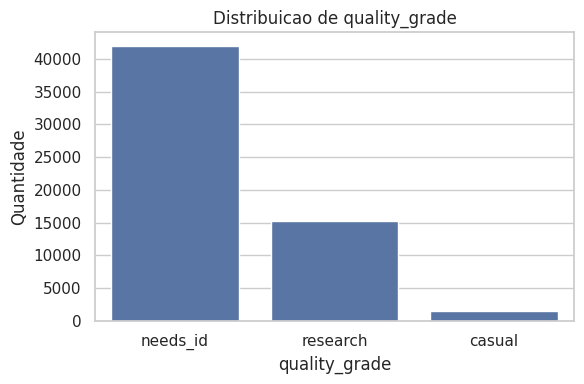


Top 15 especies (scientific_name binomial):


,count
scientific_name,
Volvopluteus gloiocephalus,3010
Schizophyllum commune,2586
Trametes versicolor,2103
Laetiporus sulphureus,1420
Lactarius deliciosus,1320
Armillaria mellea,1151
Phallus impudicus,1141
Marasmius oreades,1129
Omphalotus olearius,905


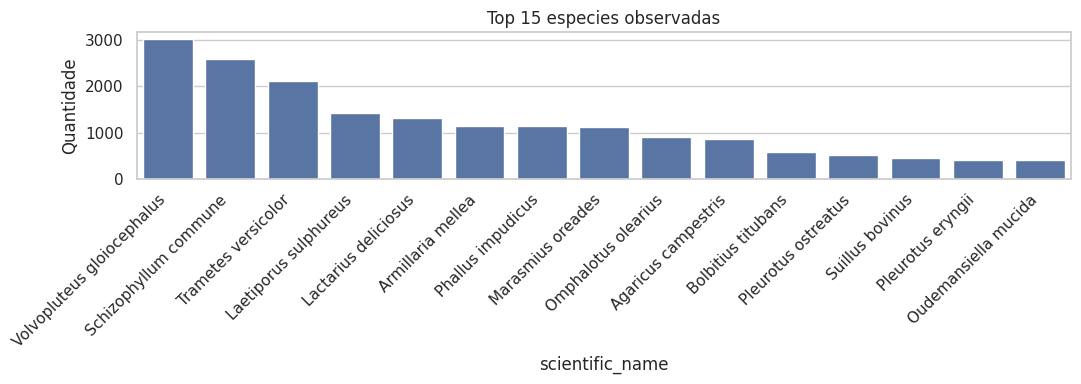

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Qualidade dos dados
missing_abs = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing_abs / len(df) * 100).round(2)
missing_table = pd.DataFrame({"missing_abs": missing_abs, "missing_pct": missing_pct})

print("Top 20 colunas com mais valores ausentes:")
display(missing_table.head(20))

n_duplicates = df.duplicated().sum()
print(f"\nLinhas duplicadas: {n_duplicates} ({n_duplicates/len(df)*100:.2f}%)")

# Distribuicao de quality_grade
if "quality_grade" in df.columns:
    q = df["quality_grade"].value_counts(dropna=False)
    qp = (df["quality_grade"].value_counts(normalize=True, dropna=False) * 100).round(2)
    print("\nDistribuicao de quality_grade:")
    display(pd.DataFrame({"count": q, "pct": qp}))

    plt.figure(figsize=(6, 4))
    sns.barplot(x=q.index.astype(str), y=q.values)
    plt.title("Distribuicao de quality_grade")
    plt.xlabel("quality_grade")
    plt.ylabel("Quantidade")
    plt.tight_layout()
    plt.show()

# Top especies binomiais
if "scientific_name" in df.columns:
    species = df["scientific_name"].dropna().astype(str)
    species = species[species.str.contains(" ")]
    top_species = species.value_counts().head(15)

    print("\nTop 15 especies (scientific_name binomial):")
    display(top_species.to_frame("count"))

    plt.figure(figsize=(11, 4))
    sns.barplot(x=top_species.index, y=top_species.values)
    plt.title("Top 15 especies observadas")
    plt.xlabel("scientific_name")
    plt.ylabel("Quantidade")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

Observacoes com coordenadas: 58710 / 58710 (100.00%)


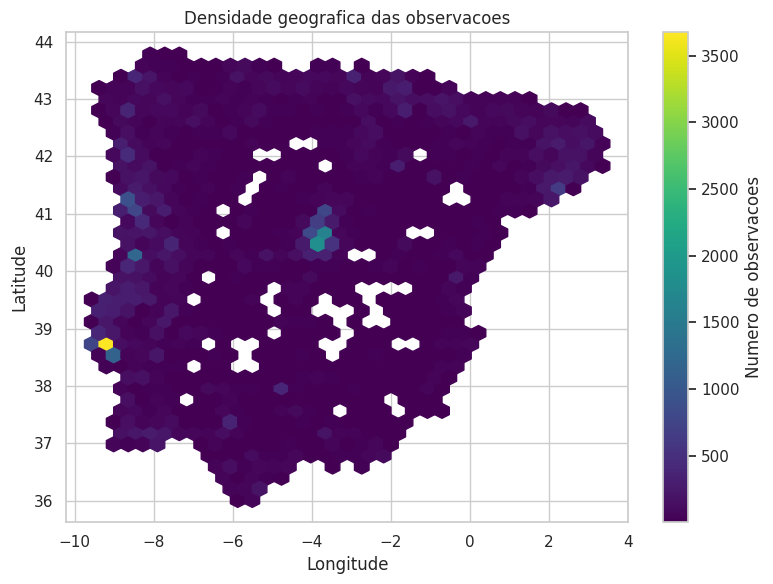

In [32]:
# Analise geografica
if {"latitude", "longitude"}.issubset(df.columns):
    geo_df = df.dropna(subset=["latitude", "longitude"]).copy()
    print(f"Observacoes com coordenadas: {len(geo_df)} / {len(df)} ({len(geo_df)/len(df)*100:.2f}%)")

    if "place_state_name" in geo_df.columns:
        top_states = geo_df["place_state_name"].fillna("(desconhecido)").value_counts().head(12)
        print("\nTop 12 estados/distritos:")
        display(top_states.to_frame("count"))

        plt.figure(figsize=(10, 4))
        sns.barplot(x=top_states.index, y=top_states.values)
        plt.title("Top estados/distritos por observacoes")
        plt.xlabel("place_state_name")
        plt.ylabel("Quantidade")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

    if "place_county_name" in geo_df.columns:
        top_counties = geo_df["place_county_name"].fillna("(desconhecido)").value_counts().head(12)
        print("\nTop 12 concelhos:")
        display(top_counties.to_frame("count"))

    plt.figure(figsize=(8, 6))
    plt.hexbin(geo_df["longitude"], geo_df["latitude"], gridsize=35, cmap="viridis", mincnt=1)
    plt.colorbar(label="Numero de observacoes")
    plt.title("Densidade geografica das observacoes")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.tight_layout()
    plt.show()
else:
    print("Colunas de latitude/longitude nao disponiveis para analise geografica.")

Observacoes por mes:


,count
month,
1,3664
2,2401
3,2530
4,2152
5,1969
6,1471
7,1192
8,1596
9,3683


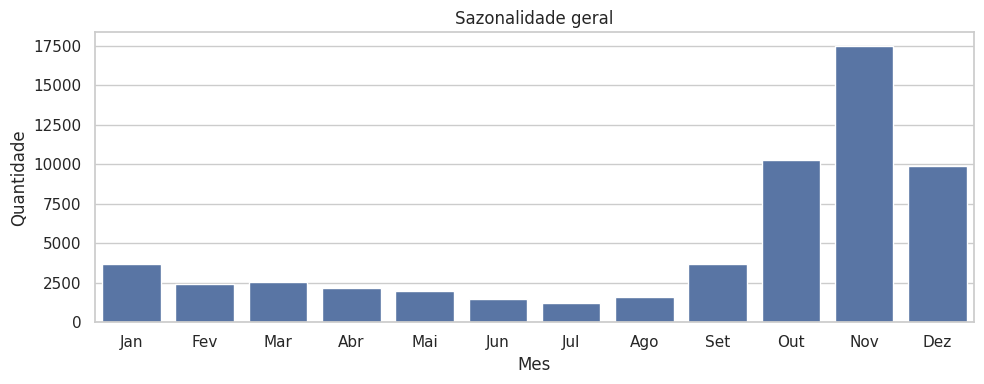


Heatmap mensal das top 8 especies:


month,1,2,3,4,5,6,7,8,9,10,11,12
scientific_name,,,,,,,,,,,,
Armillaria mellea,16,6,0,3,2,14,4,4,10,403,439,246
Lactarius deliciosus,63,7,5,1,0,3,9,11,78,288,494,348
Laetiporus sulphureus,8,3,4,16,62,36,45,343,502,279,88,20
Marasmius oreades,26,20,29,58,84,54,11,11,93,238,399,92
Phallus impudicus,105,15,5,7,20,50,103,62,27,115,327,297
Schizophyllum commune,383,370,366,238,153,81,54,67,71,149,315,331
Trametes versicolor,231,203,189,159,98,59,68,66,124,223,361,304
Volvopluteus gloiocephalus,223,54,33,13,14,8,3,7,14,170,1378,1081


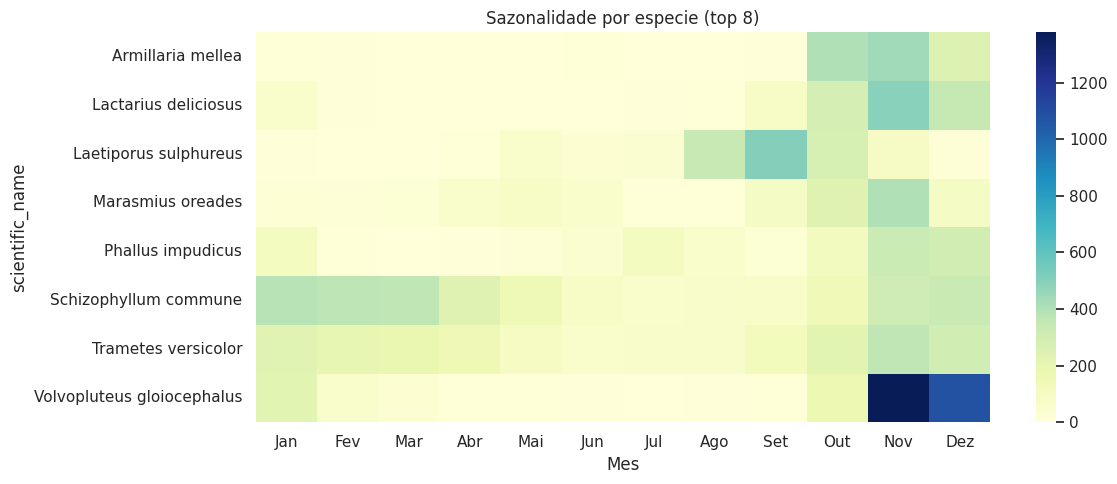

In [33]:
# Sazonalidade
if "observed_on" in df.columns:
    season_df = df.dropna(subset=["observed_on"]).copy()
    season_df["month"] = season_df["observed_on"].dt.month

    monthly_counts = season_df["month"].value_counts().sort_index()
    month_labels = ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun", "Jul", "Ago", "Set", "Out", "Nov", "Dez"]

    print("Observacoes por mes:")
    display(monthly_counts.to_frame("count"))

    plt.figure(figsize=(10, 4))
    sns.barplot(x=[month_labels[m - 1] for m in monthly_counts.index], y=monthly_counts.values)
    plt.title("Sazonalidade geral")
    plt.xlabel("Mes")
    plt.ylabel("Quantidade")
    plt.tight_layout()
    plt.show()

    if "scientific_name" in season_df.columns:
        species = season_df["scientific_name"].dropna().astype(str)
        species = species[species.str.contains(" ")]
        top_species8 = species.value_counts().head(8).index.tolist()

        sp_month = (
            season_df[season_df["scientific_name"].isin(top_species8)]
            .groupby(["scientific_name", "month"])
            .size()
            .unstack(fill_value=0)
            .reindex(columns=range(1, 13), fill_value=0)
        )

        print("\nHeatmap mensal das top 8 especies:")
        display(sp_month)

        plt.figure(figsize=(12, 5))
        sns.heatmap(sp_month, cmap="YlGnBu")
        plt.title("Sazonalidade por especie (top 8)")
        plt.xlabel("Mes")
        plt.ylabel("scientific_name")
        plt.xticks(ticks=np.arange(12) + 0.5, labels=month_labels, rotation=0)
        plt.tight_layout()
        plt.show()
else:
    print("Coluna observed_on nao disponivel para analise de sazonalidade.")

In [34]:
# Comparativo por pais e quality_grade
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

if {"place_country_name", "quality_grade"}.issubset(df.columns):
    country_df = df.copy()
    country_df["place_country_name"] = country_df["place_country_name"].fillna("(desconhecido)")

    top_countries = country_df["place_country_name"].value_counts().head(10).index
    ctab = pd.crosstab(
        country_df[country_df["place_country_name"].isin(top_countries)]["place_country_name"],
        country_df[country_df["place_country_name"].isin(top_countries)]["quality_grade"],
    )

    print("Top 10 paises por observacoes e distribuicao de quality_grade:")
    display(ctab)

    ctab.plot(kind="bar", stacked=True, figsize=(11, 5), colormap="tab20")
    plt.title("Quality grade por pais (top 10)")
    plt.xlabel("Pais")
    plt.ylabel("Quantidade")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.show()

    if "research" in ctab.columns:
        research_rate = (ctab["research"] / ctab.sum(axis=1) * 100).sort_values(ascending=False)
        print("\nPercentual de observacoes 'research' por pais:")
        display(research_rate.to_frame("research_pct"))

        plt.figure(figsize=(10, 4))
        sns.barplot(x=research_rate.index, y=research_rate.values)
        plt.title("Taxa de quality_grade=research por pais")
        plt.xlabel("Pais")
        plt.ylabel("Research (%)")
        plt.xticks(rotation=35, ha="right")
        plt.tight_layout()
        plt.show()
else:
    print("Colunas place_country_name e/ou quality_grade nao disponiveis.")

Colunas place_country_name e/ou quality_grade nao disponiveis.


In [35]:
# Evolucao temporal por pais (top 4)
if {"observed_on", "place_country_name"}.issubset(df.columns):
    ts_df = df.dropna(subset=["observed_on"]).copy()
    ts_df["country"] = ts_df["place_country_name"].fillna("(desconhecido)")

    # Remove timezone antes de converter para mes para evitar warning e facilitar o plot
    ts_df["year_month"] = (
        ts_df["observed_on"]
        .dt.tz_localize(None)
        .dt.to_period("M")
        .dt.to_timestamp()
    )

    top4 = ts_df["country"].value_counts().head(4).index.tolist()
    ts_top = ts_df[ts_df["country"].isin(top4)]

    monthly_country = (
        ts_top.groupby(["year_month", "country"])
        .size()
        .reset_index(name="count")
    )

    print("Serie mensal por pais (top 4):")
    display(monthly_country.head(20))

    plt.figure(figsize=(13, 5))
    sns.lineplot(data=monthly_country, x="year_month", y="count", hue="country")
    plt.title("Evolucao mensal de observacoes por pais (top 4)")
    plt.xlabel("Ano-Mes")
    plt.ylabel("Quantidade")
    plt.tight_layout()
    plt.show()

    # Agregado anual para reduzir ruido e facilitar comparacao
    ts_df["year"] = ts_df["observed_on"].dt.year
    yearly_country = (
        ts_df[ts_df["country"].isin(top4)]
        .groupby(["year", "country"])
        .size()
        .reset_index(name="count")
    )

    years_order = sorted(yearly_country["year"].dropna().unique().tolist())
    step = 1 if len(years_order) <= 15 else 2 if len(years_order) <= 30 else 3

    plt.figure(figsize=(11, 5))
    ax = sns.barplot(data=yearly_country, x="year", y="count", hue="country", order=years_order)
    plt.title("Observacoes anuais por pais (top 4)")
    plt.xlabel("Ano")
    plt.ylabel("Quantidade")

    tick_pos = list(range(0, len(years_order), step))
    tick_lbl = [str(years_order[i]) for i in tick_pos]
    ax.set_xticks(tick_pos)
    ax.set_xticklabels(tick_lbl, rotation=45, ha="right")

    plt.tight_layout()
    plt.show()
else:
    print("Colunas observed_on e/ou place_country_name nao disponiveis.")

Colunas observed_on e/ou place_country_name nao disponiveis.



Top 15 utilizadores por numero de observacoes:


,count
user_login,
maremimar,837
angel_fernandez_cancio,797
amanithor,743
jonatan_antunez,529
deinonyco,444
rodrimarquez,385
jonnyvanbatman,383
luisballester,337
brandao,296


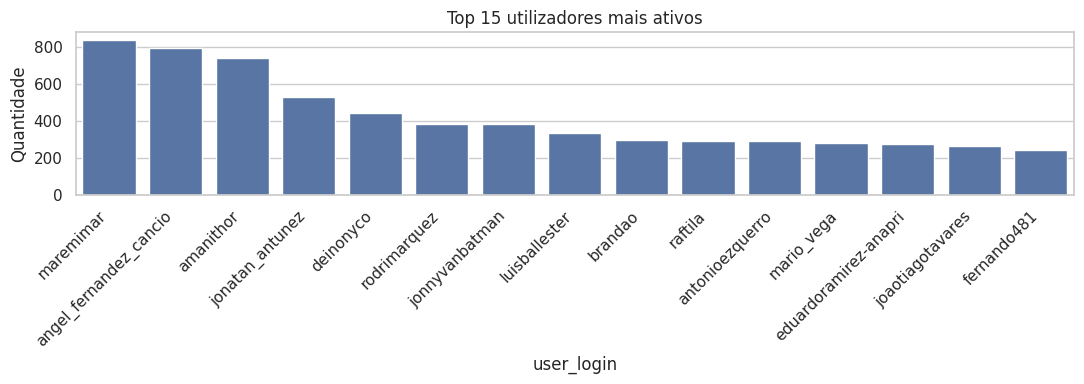

In [36]:
# Diversidade por estado/distrito e top observadores
if {"place_state_name", "scientific_name"}.issubset(df.columns):
    div_df = df.copy()
    div_df["state"] = div_df["place_state_name"].fillna("(desconhecido)")
    div_df["scientific_name"] = div_df["scientific_name"].fillna("(nao identificado)")

    state_stats = (
        div_df.groupby("state")
        .agg(
            observacoes=("id", "count"),
            especies_unicas=("scientific_name", "nunique")
        )
        .sort_values("observacoes", ascending=False)
    )

    top12_states = state_stats.head(12)
    print("Top 12 estados/distritos: observacoes e diversidade de especies:")
    display(top12_states)

    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=top12_states.reset_index(),
        x="observacoes", y="especies_unicas", size="observacoes", hue="state", legend=False
    )
    plt.title("Diversidade vs volume de observacoes (top 12 estados)")
    plt.xlabel("Numero de observacoes")
    plt.ylabel("Numero de especies unicas")
    plt.tight_layout()
    plt.show()

if "user_login" in df.columns:
    top_users = df["user_login"].fillna("(desconhecido)").value_counts().head(15)
    print("\nTop 15 utilizadores por numero de observacoes:")
    display(top_users.to_frame("count"))

    plt.figure(figsize=(11, 4))
    sns.barplot(x=top_users.index, y=top_users.values)
    plt.title("Top 15 utilizadores mais ativos")
    plt.xlabel("user_login")
    plt.ylabel("Quantidade")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## Preparacao para Tableau (DW + Data Marts)

A partir desta secao, o notebook cria um modelo estrela e tabelas agregadas para dashboards no Tableau.

Saidas geradas em `tableau_exports/`:
- `dim_species.csv`
- `dim_location.csv`
- `dim_time.csv`
- `fact_mushroom_observation.csv`
- `mart_country_year_quality.csv`
- `mart_species_season_region.csv`
- `mart_state_risk_diversity.csv`

In [37]:
# Lista todas as especies no dataset
if "scientific_name" in df.columns:
    print(f"Count: {len(df['scientific_name'].dropna().unique())}")
    all_species = df["scientific_name"].dropna().unique()
    for sp in sorted(all_species):
        print(f"{sp}")
else:
    print("Coluna scientific_name nao disponivel para listar especies.")

Count: 346
Abortiporus biennis
Agaricaceae
Agaricales
Agaricineae
Agaricomycetes
Agaricus
Agaricus arvensis
Agaricus augustus
Agaricus bisporus
Agaricus bitorquis
Agaricus bohusii
Agaricus brunneolus
Agaricus campestris
Agaricus comtulus
Agaricus crocodilinus
Agaricus cupreobrunneus
Agaricus dulcidulus
Agaricus impudicus
Agaricus incultorum
Agaricus langei
Agaricus litoralis
Agaricus matrum
Agaricus moelleri
Agaricus moelleroides
Agaricus placomyces
Agaricus pseudopratensis
Agaricus subrufescens
Agaricus sylvaticus
Agaricus sylvicola
Agaricus xanthodermus
Aleuria aurantia
Amanita
Amanita caesarea
Amanita citrina
Amanita curtipes
Amanita gioiosa
Amanita muscaria
Amanita ponderosa
Amanita rubescens
Amanita verna
Amanitaceae
Anacamptis papilionacea
Armillaria
Armillaria mellea
Armillaria novae-zelandiae
Armillaria ostoyae
Arrhenia
Asterophora parasitica
Astraeus hygrometricus
Auricularia mesenterica
Auricularia nigricans
Auricularia polytricha
Basidiomycota
Battarrea phalloides
Berkcurtia

In [38]:
from pathlib import Path

# =============================
# 1) Feature engineering base
# =============================
dw = df.copy().reset_index(drop=True)

# obs_id robusto (usa id quando existe, senao indice + 1)
dw["obs_id"] = dw.get("id", pd.Series(index=dw.index, dtype="float64"))
missing_obs_id = dw["obs_id"].isna()
dw.loc[missing_obs_id, "obs_id"] = (dw.index[missing_obs_id] + 1).astype(float)
dw["obs_id"] = dw["obs_id"].astype("int64")

# Datas e componentes temporais
dw["observation_date"] = pd.to_datetime(dw.get("observed_on"), errors="coerce", utc=True).dt.tz_localize(None)
dw["year"] = dw["observation_date"].dt.year
dw["month"] = dw["observation_date"].dt.month
dw["week"] = dw["observation_date"].dt.isocalendar().week.astype("Int64")
dw["day_of_week"] = dw["observation_date"].dt.day_name().fillna("Unknown")

def month_to_season(m):
    if pd.isna(m):
        return "unknown"
    m = int(m)
    if m in (12, 1, 2):
        return "winter"
    if m in (3, 4, 5):
        return "spring"
    if m in (6, 7, 8):
        return "summer"
    return "autumn"

dw["season"] = dw["month"].apply(month_to_season)

# Regiao norte/sul (proxy simples para Iberia)
dw["region_pt"] = np.where(dw.get("latitude", pd.Series([np.nan] * len(dw))).fillna(0) >= 40.5, "norte", "sul")

# Habitat proxy a partir de metadados disponiveis
if "place_county_name" in dw.columns:
    dw["habitat_type"] = dw["place_county_name"].fillna("unknown")
else:
    dw["habitat_type"] = "unknown"

# Metrica de media por observacao
dw["media_count"] = 0
dw["media_count"] += dw.get("image_url", pd.Series(index=dw.index)).notna().astype(int)
dw["media_count"] += dw.get("sound_url", pd.Series(index=dw.index)).notna().astype(int)
dw["observation_count"] = 1

# Edibilidade: mapeamento parcial (resto = desconhecido)
toxic_species = {
    "Amanita phalloides", "Amanita muscaria", "Amanita pantherina", "Omphalotus olearius"
}
edible_species = {
    "Pleurotus ostreatus", "Pleurotus eryngii", "Boletus edulis", "Lactarius deliciosus", "Agaricus campestris"
}

dw["scientific_name"] = dw.get("scientific_name", pd.Series([np.nan] * len(dw))).astype("string")
sci = dw["scientific_name"].fillna("")
dw["edibility_status"] = np.where(sci.isin(toxic_species), "poisonous", np.where(sci.isin(edible_species), "edible", "unknown"))
dw["edible"] = np.where(dw["edibility_status"] == "edible", 1, np.where(dw["edibility_status"] == "poisonous", 0, np.nan))
dw["toxicity_level"] = np.where(dw["edibility_status"] == "poisonous", "high", np.where(dw["edibility_status"] == "edible", "low", "unknown"))

# =============================
# 2) Dimensoes
# =============================
for c in ["common_name", "taxon_family_name", "latitude", "longitude", "place_country_name", "place_state_name", "place_county_name"]:
    if c not in dw.columns:
        dw[c] = np.nan

dim_species = (
    dw[["scientific_name", "common_name", "taxon_family_name", "edibility_status", "toxicity_level"]]
    .rename(columns={"taxon_family_name": "family"})
    .drop_duplicates()
    .reset_index(drop=True)
)
dim_species.insert(0, "species_id", np.arange(1, len(dim_species) + 1))

dim_location = (
    dw[["latitude", "longitude", "region_pt", "habitat_type", "place_country_name", "place_state_name", "place_county_name"]]
    .rename(columns={"place_country_name": "country", "place_state_name": "state", "place_county_name": "county"})
    .drop_duplicates()
    .reset_index(drop=True)
)
dim_location.insert(0, "location_id", np.arange(1, len(dim_location) + 1))

dim_time = (
    dw[["observation_date", "year", "month", "season", "week", "day_of_week"]]
    .drop_duplicates()
    .reset_index(drop=True)
)
dim_time.insert(0, "time_id", np.arange(1, len(dim_time) + 1))

# =============================
# 3) Fato (via merge robusto)
# =============================
fact = dw.merge(
    dim_species,
    left_on=["scientific_name", "common_name", "taxon_family_name", "edibility_status", "toxicity_level"],
    right_on=["scientific_name", "common_name", "family", "edibility_status", "toxicity_level"],
    how="left",
)

fact = fact.rename(columns={"place_country_name": "country", "place_state_name": "state", "place_county_name": "county"})
fact = fact.merge(
    dim_location,
    on=["latitude", "longitude", "region_pt", "habitat_type", "country", "state", "county"],
    how="left",
)

fact = fact.merge(
    dim_time,
    on=["observation_date", "year", "month", "season", "week", "day_of_week"],
    how="left",
)

fact_mushroom_observation = fact[[
    "obs_id", "species_id", "location_id", "time_id", "edible", "observation_count", "media_count"
]].copy()

# =============================
# 4) Export CSVs para Tableau
# =============================
out_dir = Path("tableau_exports")
out_dir.mkdir(parents=True, exist_ok=True)

dim_species.to_csv(out_dir / "dim_species.csv", index=False)
dim_location.to_csv(out_dir / "dim_location.csv", index=False)
dim_time.to_csv(out_dir / "dim_time.csv", index=False)
fact_mushroom_observation.to_csv(out_dir / "fact_mushroom_observation.csv", index=False)

print("Arquivos DW exportados em:", out_dir)
print("dim_species:", dim_species.shape)
print("dim_location:", dim_location.shape)
print("dim_time:", dim_time.shape)
print("fact_mushroom_observation:", fact_mushroom_observation.shape)

Arquivos DW exportados em: tableau_exports
dim_species: (350, 6)
dim_location: (54423, 8)
dim_time: (3912, 7)
fact_mushroom_observation: (58710, 7)


In [39]:
# Data marts para dashboards no Tableau
from pathlib import Path

out_dir = Path("tableau_exports")
out_dir.mkdir(parents=True, exist_ok=True)

# Garante base DW minima, caso a celula anterior nao tenha sido executada
if "dw" not in globals():
    dw = df.copy()
    dw["observation_date"] = pd.to_datetime(dw.get("observed_on"), errors="coerce", utc=True).dt.tz_localize(None)
    dw["month"] = dw["observation_date"].dt.month
    dw["season"] = dw["month"].map({12: "winter", 1: "winter", 2: "winter", 3: "spring", 4: "spring", 5: "spring", 6: "summer", 7: "summer", 8: "summer", 9: "autumn", 10: "autumn", 11: "autumn"}).fillna("unknown")
    dw["region_pt"] = np.where(dw.get("latitude", pd.Series([np.nan] * len(dw))).fillna(0) >= 40.5, "norte", "sul")
    dw["obs_id"] = dw.get("id", pd.Series(index=dw.index)).fillna(pd.Series(dw.index + 1, index=dw.index)).astype("int64")
    if "edible" not in dw.columns:
        dw["edible"] = np.nan

# 1) Pais x Ano x Quality
mart_country_year_quality = (
    df.assign(
        observed_on=pd.to_datetime(df["observed_on"], errors="coerce", utc=True).dt.tz_localize(None),
        country=df["place_country_name"].fillna("(desconhecido)") if "place_country_name" in df.columns else "(desconhecido)",
        quality_grade=df["quality_grade"].fillna("unknown") if "quality_grade" in df.columns else "unknown"
    )
    .assign(year=lambda x: x["observed_on"].dt.year)
    .groupby(["country", "year", "quality_grade"], dropna=False)
    .size()
    .reset_index(name="observation_count")
)

# 2) Especie x Estacao x Regiao
mart_species_season_region = (
    dw.assign(species_name=dw.get("scientific_name", pd.Series(["(unknown)"] * len(dw))).fillna("(unknown)"))
    .groupby(["species_name", "season", "region_pt"], dropna=False)
    .size()
    .reset_index(name="observation_count")
)

# 3) Estado x risco x diversidade
state_div = (
    dw.assign(
        state=dw.get("place_state_name", pd.Series(["(desconhecido)"] * len(dw))).fillna("(desconhecido)"),
        species_name=dw.get("scientific_name", pd.Series(["(unknown)"] * len(dw))).fillna("(unknown)")
    )
    .groupby("state", dropna=False)
    .agg(
        observations=("obs_id", "count"),
        species_diversity=("species_name", "nunique"),
        known_edible_ratio=("edible", "mean")
    )
    .reset_index()
)
mart_state_risk_diversity = state_div

mart_country_year_quality.to_csv(out_dir / "mart_country_year_quality.csv", index=False)
mart_species_season_region.to_csv(out_dir / "mart_species_season_region.csv", index=False)
mart_state_risk_diversity.to_csv(out_dir / "mart_state_risk_diversity.csv", index=False)

print("Data marts exportados:")
print("-", out_dir / "mart_country_year_quality.csv", mart_country_year_quality.shape)
print("-", out_dir / "mart_species_season_region.csv", mart_species_season_region.shape)
print("-", out_dir / "mart_state_risk_diversity.csv", mart_state_risk_diversity.shape)

display(mart_country_year_quality.head(10))
display(mart_species_season_region.head(10))
display(mart_state_risk_diversity.head(10))

Data marts exportados:
- tableau_exports/mart_country_year_quality.csv (91, 4)
- tableau_exports/mart_species_season_region.csv (935, 4)
- tableau_exports/mart_state_risk_diversity.csv (1, 4)


,country,year,quality_grade,observation_count
0,(desconhecido),1981.0,needs_id,1
1,(desconhecido),1981.0,research,1
2,(desconhecido),1982.0,needs_id,2
3,(desconhecido),1983.0,needs_id,4
4,(desconhecido),1983.0,research,2
5,(desconhecido),1984.0,needs_id,1
6,(desconhecido),1986.0,needs_id,1
7,(desconhecido),1987.0,research,1
8,(desconhecido),1992.0,needs_id,2
9,(desconhecido),1992.0,research,1


,species_name,season,region_pt,observation_count
0,Abortiporus biennis,autumn,sul,1
1,Abortiporus biennis,summer,sul,1
2,Agaricaceae,autumn,norte,312
3,Agaricaceae,autumn,sul,217
4,Agaricaceae,spring,norte,18
5,Agaricaceae,spring,sul,22
6,Agaricaceae,summer,norte,32
7,Agaricaceae,summer,sul,13
8,Agaricaceae,unknown,norte,3
9,Agaricaceae,unknown,sul,1


,state,observations,species_diversity,known_edible_ratio
0,(desconhecido),58710,346,0.771579


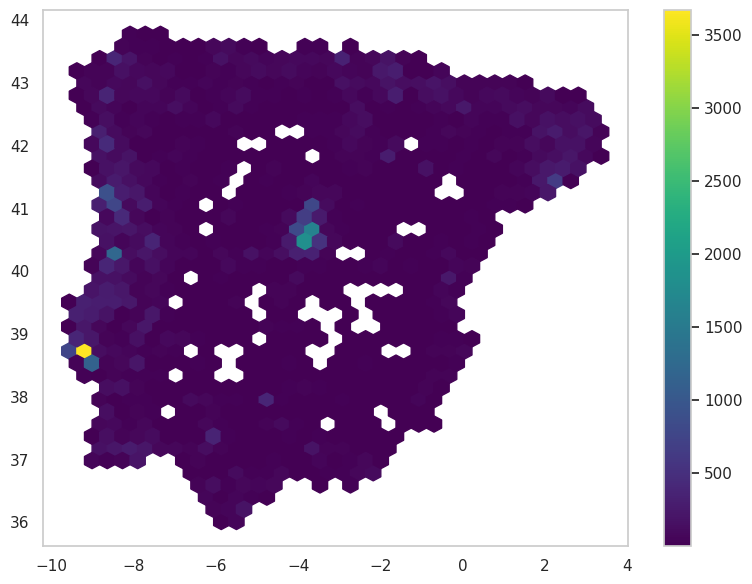

In [40]:
# Analise geografica (apenas figura + legenda de cor, sem grid)
if {"latitude", "longitude"}.issubset(df.columns):
    geo_df = df.dropna(subset=["latitude", "longitude"]).copy()

    fig, ax = plt.subplots(figsize=(8, 6))
    hb = ax.hexbin(
        geo_df["longitude"],
        geo_df["latitude"],
        gridsize=35,
        cmap="viridis",
        mincnt=1,
    )
    cbar = fig.colorbar(hb, ax=ax)
    ax.grid(False)

    plt.tight_layout()
    plt.show()
else:
    print("Colunas de latitude/longitude nao disponiveis para analise geografica.")

## Mockups Iniciais DW/DM (Draft)

Nesta secao, os graficos usam dados reais quando disponiveis e completam com dados sinteticos quando necessario.

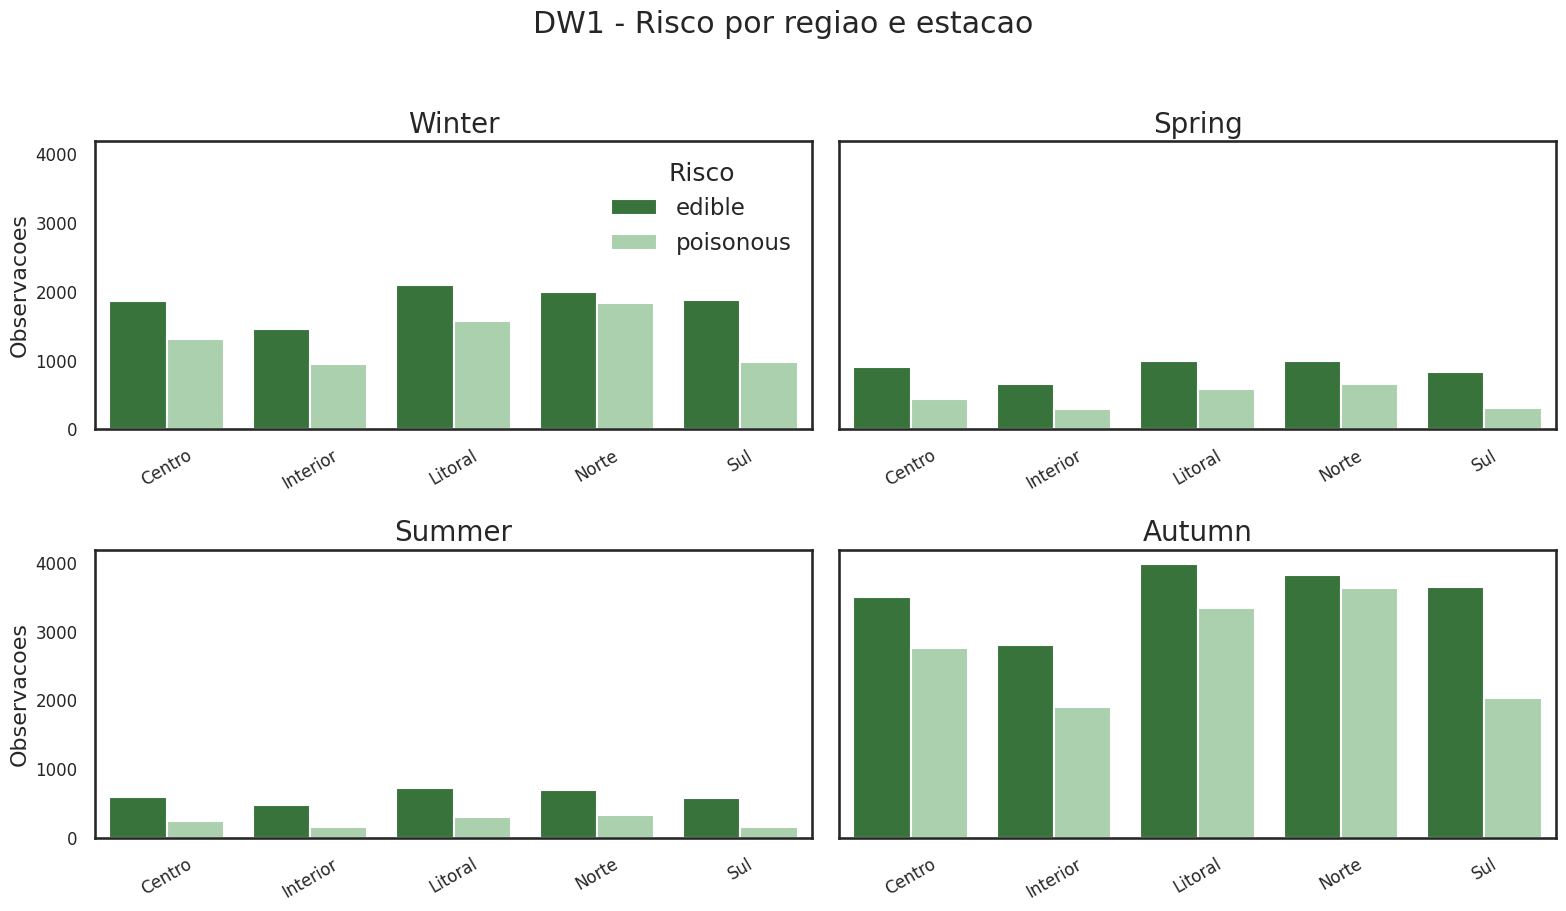

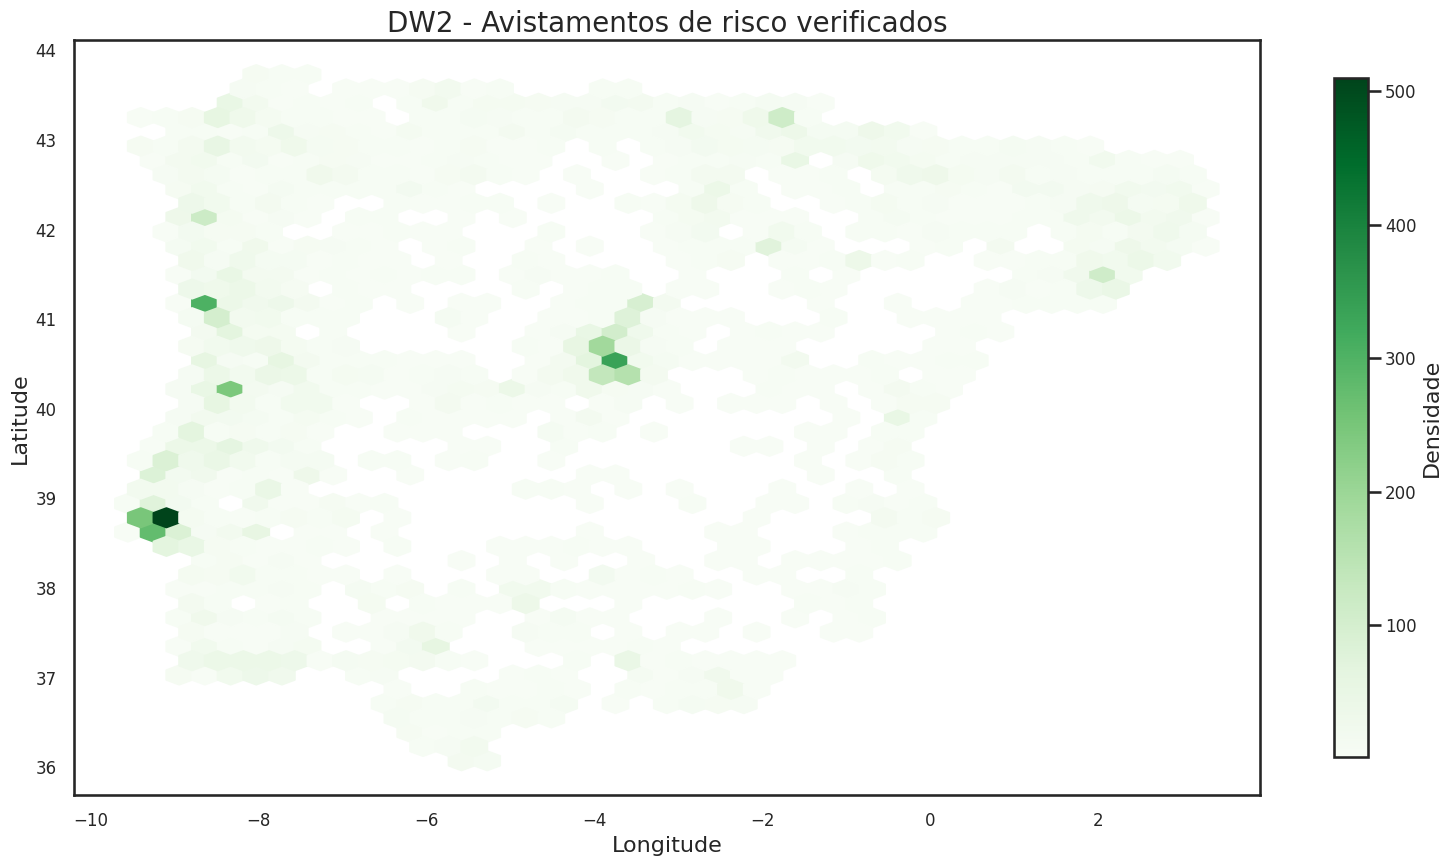

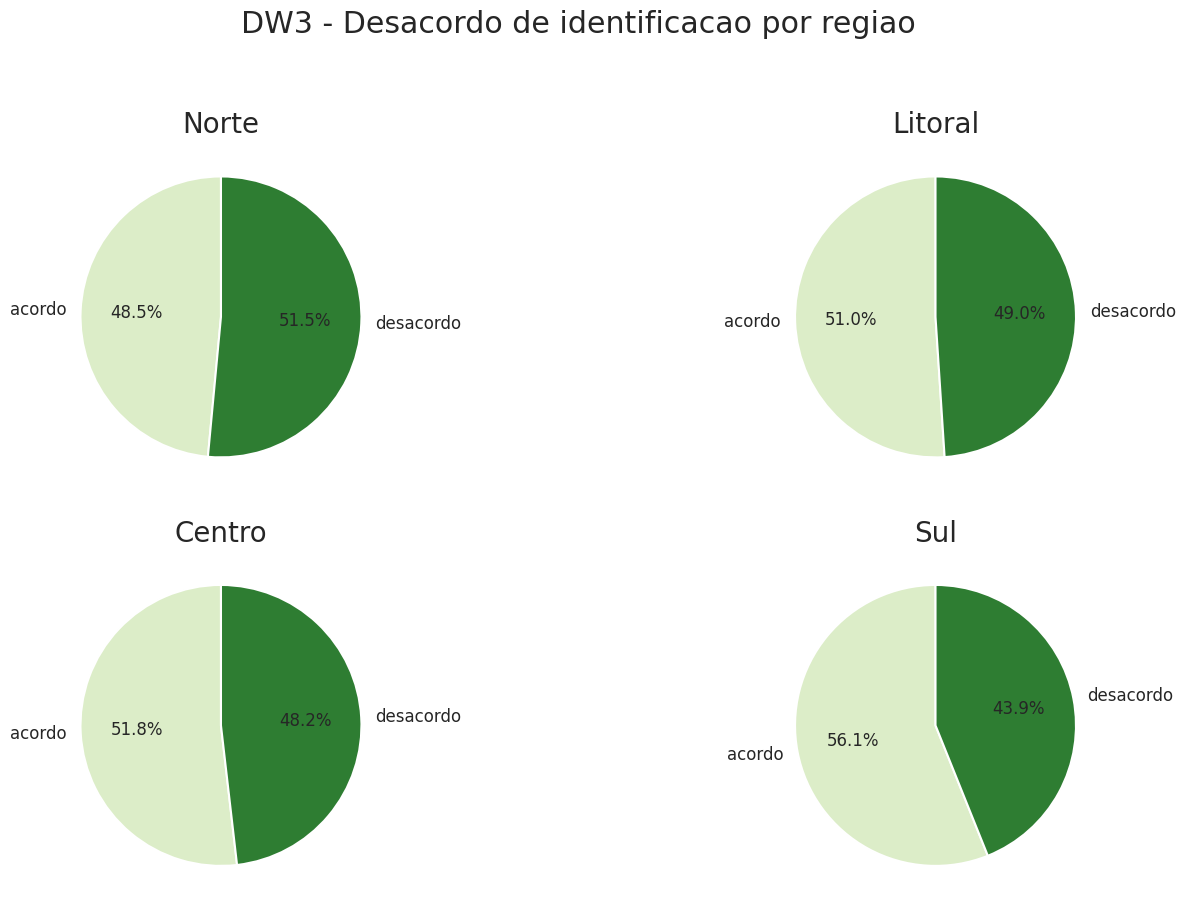

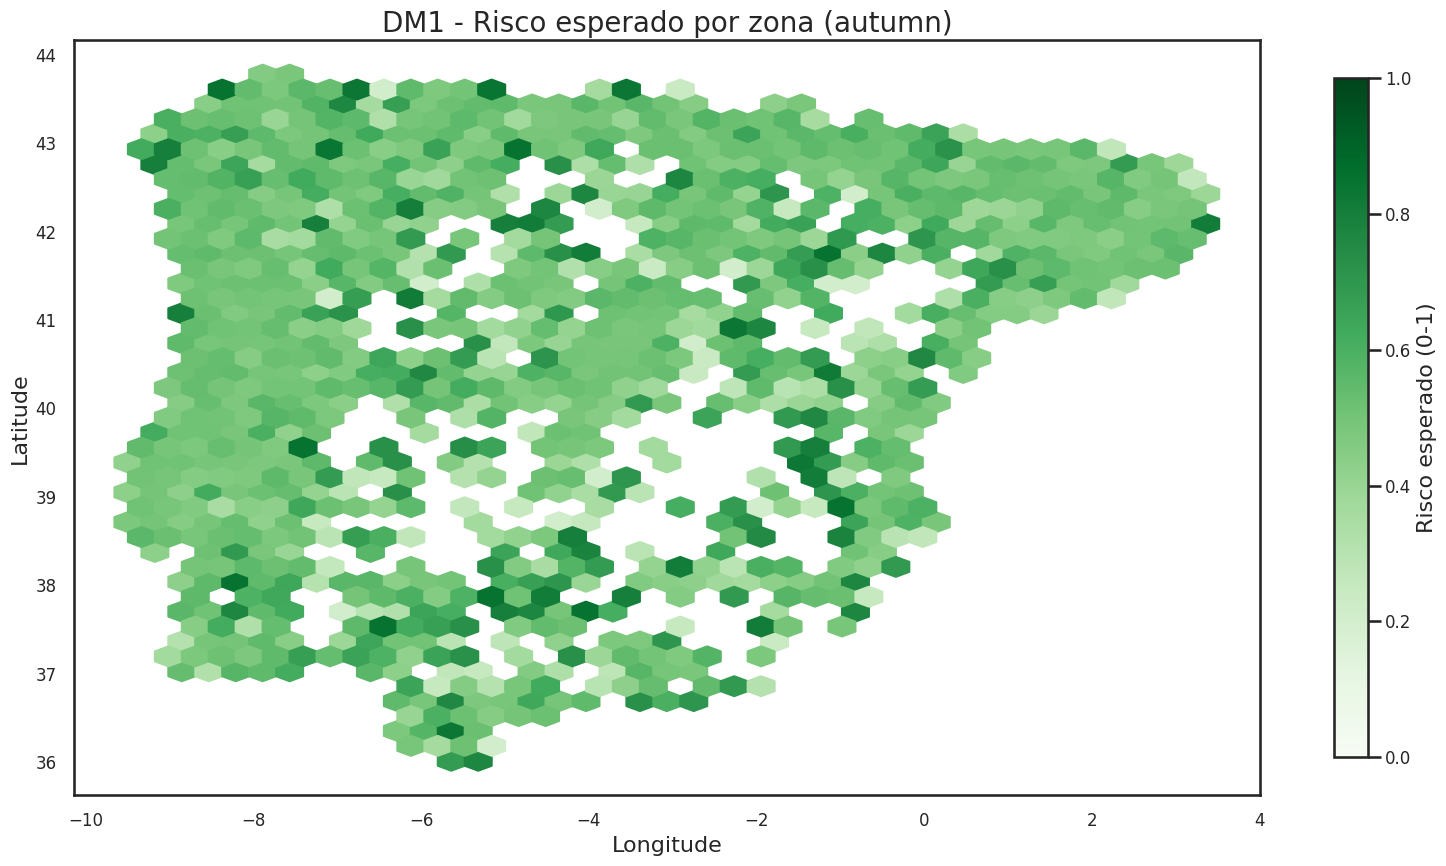

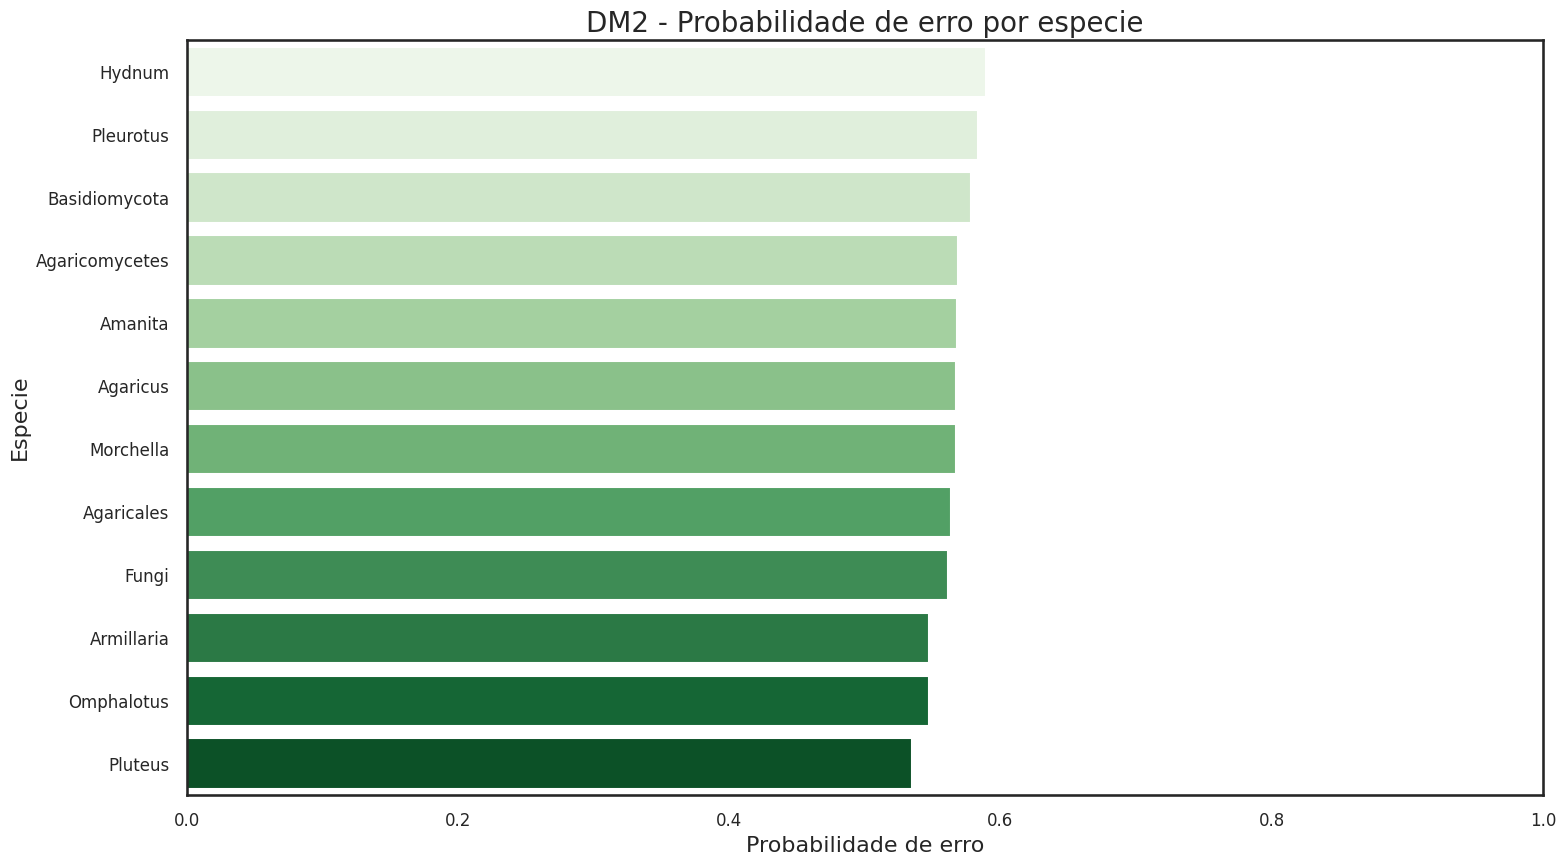

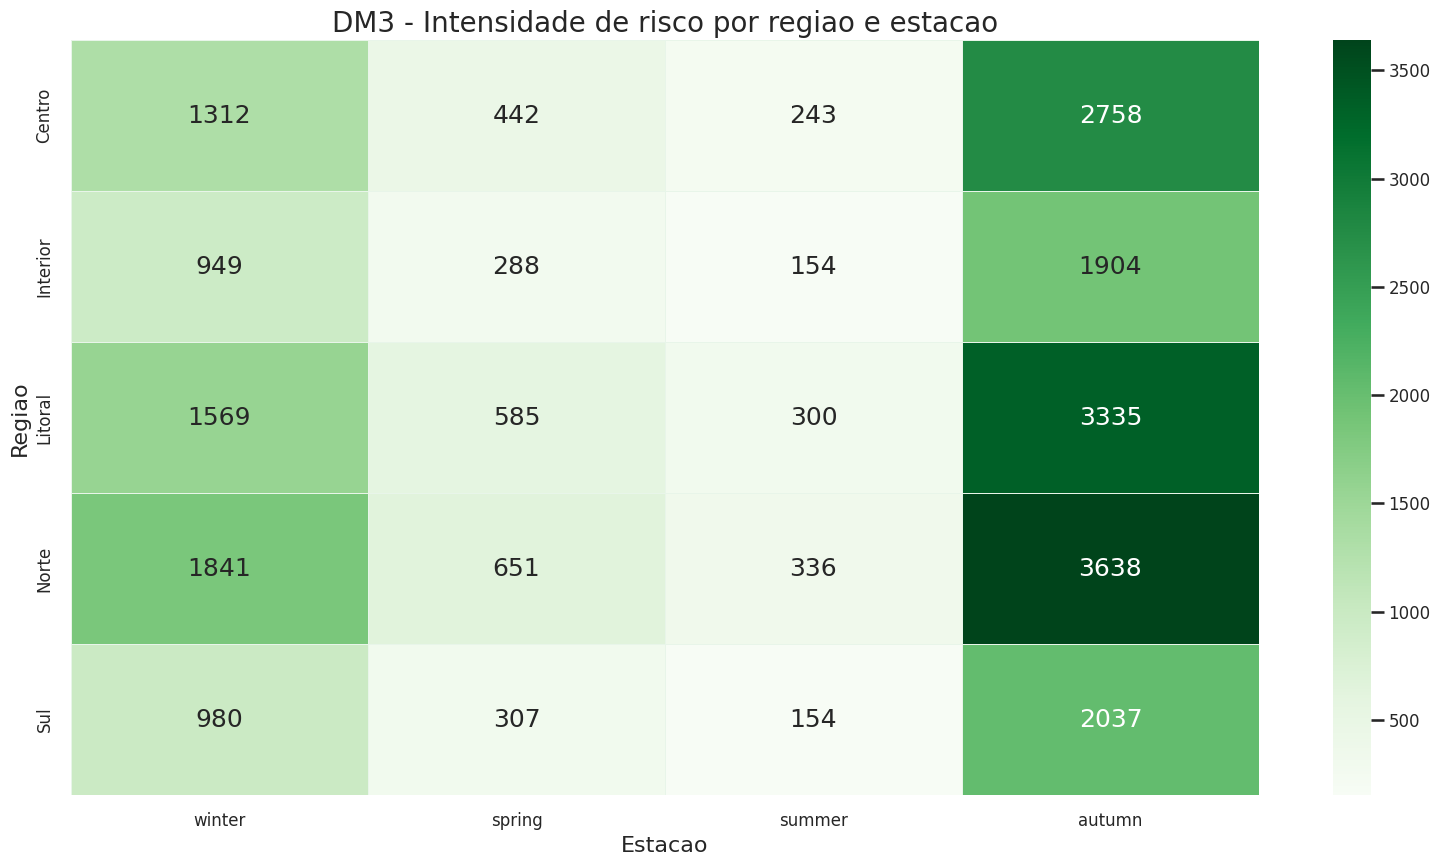

Mockups exportados:
- tableau_exports/mockup_figs/DW1_risco_regiao_estacao.png
- tableau_exports/mockup_figs/DW2_mapa_risco_verificado.png
- tableau_exports/mockup_figs/DW3_desacordo_identificacao.png
- tableau_exports/mockup_figs/DM1_mapa_risco_esperado_autumn.png
- tableau_exports/mockup_figs/DM2_probabilidade_erro_especie.png
- tableau_exports/mockup_figs/DM3_intensidade_risco_regiao_estacao.png


In [41]:
# Mockups DW/DM (poster-ready + export PNG): DW1, DW2, DW3, DM1, DM2 e DM3
from pathlib import Path

rng = np.random.default_rng(42)

# Estilo visual para poster (16:9, limpo e consistente)
sns.set_theme(style="white", context="talk")
plt.rcParams["figure.figsize"] = (16, 9)
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["axes.labelsize"] = 16
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12

GREEN_DARK = "#1b5e20"
GREEN_MID = "#2e7d32"
GREEN_LIGHT = "#a5d6a7"
GREEN_PALE = "#dcedc8"

# Export setup
export_dir = Path("tableau_exports/mockup_figs")
export_dir.mkdir(parents=True, exist_ok=True)
SAVE_DPI = 320
saved_files = []

def save_fig(fig, filename):
    out = export_dir / f"{filename}.png"
    fig.savefig(out, dpi=SAVE_DPI, bbox_inches="tight", facecolor="white")
    saved_files.append(str(out))

mock = df.copy()

# =============================
# 1) Campos base + fallback sintetico com maior variacao
# =============================
if "region_pt" in mock.columns:
    mock["region"] = mock["region_pt"].fillna("desconhecido").astype(str)
elif "place_state_name" in mock.columns:
    mock["region"] = mock["place_state_name"].fillna("desconhecido").astype(str)
elif "place_country_name" in mock.columns:
    mock["region"] = mock["place_country_name"].fillna("desconhecido").astype(str)
else:
    region_pool = np.array(["Norte", "Centro", "Sul", "Litoral", "Interior"])
    region_p = np.array([0.24, 0.20, 0.18, 0.23, 0.15])
    mock["region"] = rng.choice(region_pool, size=len(mock), p=region_p, replace=True)

if "observed_on" in mock.columns:
    dt = pd.to_datetime(mock["observed_on"], errors="coerce", utc=True)
    month = dt.dt.month
    mock["season"] = month.map({12: "winter", 1: "winter", 2: "winter", 3: "spring", 4: "spring", 5: "spring", 6: "summer", 7: "summer", 8: "summer", 9: "autumn", 10: "autumn", 11: "autumn"})
else:
    mock["season"] = rng.choice(["winter", "spring", "summer", "autumn"], size=len(mock), p=[0.30, 0.22, 0.14, 0.34], replace=True)

if "scientific_name" in mock.columns:
    mock["species_name"] = mock["scientific_name"].fillna("(unknown)").astype(str)
else:
    mock["species_name"] = rng.choice(
        ["Amanita sp.", "Boletus sp.", "Lactarius sp.", "Russula sp.", "Pleurotus sp.", "Sparassis sp."],
        size=len(mock),
        replace=True,
    )

# Varia risco por regiao + estacao + especie (quando nao existir rotulo real)
region_effect = {
    "Norte": 0.08,
    "Centro": 0.03,
    "Sul": -0.04,
    "Litoral": 0.05,
    "Interior": 0.00,
    "desconhecido": 0.00,
}
season_effect = {"winter": 0.09, "spring": 0.02, "summer": -0.05, "autumn": 0.11}

if "edibility_status" in mock.columns:
    real_status = mock["edibility_status"].astype(str).str.lower()
    unknown_mask = ~real_status.isin(["poisonous", "edible"])

    # Usa valor real quando existe
    risk_bool = real_status.eq("poisonous")

    # Para unknown, sintetiza com variacao
    species_bias = (mock["species_name"].str.len() % 9) / 100.0 - 0.04
    p_unknown = (
        0.30
        + mock["region"].map(region_effect).fillna(0)
        + mock["season"].map(season_effect).fillna(0)
        + species_bias
    ).clip(0.08, 0.82)
    sampled_unknown = rng.random(len(mock)) < p_unknown
    risk_bool = np.where(unknown_mask, sampled_unknown, risk_bool)

    mock["risk_type"] = np.where(risk_bool, "poisonous", "edible")
elif "edible" in mock.columns:
    known = mock["edible"].isin([0, 1])
    risk_bool = mock["edible"].eq(0)

    species_bias = (mock["species_name"].str.len() % 9) / 100.0 - 0.04
    p_unknown = (
        0.30
        + mock["region"].map(region_effect).fillna(0)
        + mock["season"].map(season_effect).fillna(0)
        + species_bias
    ).clip(0.08, 0.82)
    sampled_unknown = rng.random(len(mock)) < p_unknown
    risk_bool = np.where(~known, sampled_unknown, risk_bool)

    mock["risk_type"] = np.where(risk_bool, "poisonous", "edible")
else:
    species_bias = (mock["species_name"].str.len() % 9) / 100.0 - 0.04
    p_poison = (
        0.30
        + mock["region"].map(region_effect).fillna(0)
        + mock["season"].map(season_effect).fillna(0)
        + species_bias
    ).clip(0.08, 0.82)
    mock["risk_type"] = np.where(rng.random(len(mock)) < p_poison, "poisonous", "edible")

# Proxy de observacao verificada
if "quality_grade" in mock.columns:
    qg = mock["quality_grade"].astype(str).str.lower()
    mock["verified"] = qg.eq("research") | ((qg.eq("needs_id")) & (rng.random(len(mock)) < 0.35))
else:
    p_verified = (0.50 - 0.15 * (mock["risk_type"] == "poisonous").astype(float)).clip(0.15, 0.85)
    mock["verified"] = rng.random(len(mock)) < p_verified

# Proxy de desacordo de identificacao (mais variado)
if "quality_grade" in mock.columns:
    qg = mock["quality_grade"].astype(str).str.lower()
    base_disagree = np.where(
        qg.eq("research"), 0.16,
        np.where(qg.eq("needs_id"), 0.48, 0.62)
    )
else:
    base_disagree = np.where(mock["risk_type"].eq("poisonous"), 0.46, 0.24)

# Ajustes adicionais por estacao/regiao
p_disagree = (
    base_disagree
    + 0.10 * mock["risk_type"].eq("poisonous").astype(float)
    + mock["season"].map({"winter": 0.06, "spring": 0.01, "summer": -0.04, "autumn": 0.03}).fillna(0)
    + mock["region"].map({"Norte": 0.04, "Centro": 0.01, "Sul": -0.03, "Litoral": 0.02, "Interior": 0.00, "desconhecido": 0.00}).fillna(0)
).clip(0.05, 0.92)

mock["id_disagreement"] = rng.random(len(mock)) < p_disagree

# Coordenadas para mapa
if "latitude" not in mock.columns or "longitude" not in mock.columns:
    mock["latitude"] = 36 + rng.random(len(mock)) * 8
    mock["longitude"] = -9.5 + rng.random(len(mock)) * 9

mock_geo = mock.dropna(subset=["latitude", "longitude"]).copy()
season_order = ["winter", "spring", "summer", "autumn"]

# =============================
# DW1 — Barras por regiao/estacao com risco
# =============================
dw1 = (
    mock.groupby(["region", "season", "risk_type"], dropna=False)
    .size()
    .reset_index(name="obs")
)

top_regions = dw1.groupby("region")["obs"].sum().sort_values(ascending=False).head(8).index
dw1_plot = dw1[dw1["region"].isin(top_regions)].copy()
dw1_plot["season"] = pd.Categorical(dw1_plot["season"], season_order)
dw1_plot = dw1_plot.sort_values(["season", "region", "risk_type"])

fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharey=True)
for i, season in enumerate(season_order):
    ax = axes.ravel()[i]
    sub = dw1_plot[dw1_plot["season"] == season]
    sns.barplot(
        data=sub,
        x="region",
        y="obs",
        hue="risk_type",
        hue_order=["edible", "poisonous"],
        palette={"edible": GREEN_MID, "poisonous": GREEN_LIGHT},
        ax=ax,
    )
    ax.set_title(season.title())
    ax.set_xlabel("")
    ax.set_ylabel("Observacoes")
    ax.tick_params(axis="x", rotation=30)
    if i != 0:
        ax.get_legend().remove()
    else:
        ax.legend(title="Risco", frameon=False)

fig.suptitle("DW1 - Risco por regiao e estacao", y=1.02)
plt.tight_layout()
save_fig(fig, "DW1_risco_regiao_estacao")
plt.show()

# =============================
# DW2 — Mapa de calor risco verificado
# =============================
dw2 = mock_geo[(mock_geo["risk_type"] == "poisonous") & (mock_geo["verified"])].copy()

if len(dw2) > 0:
    fig, ax = plt.subplots(figsize=(16, 9))
    hb = ax.hexbin(
        dw2["longitude"],
        dw2["latitude"],
        gridsize=42,
        cmap="Greens",
        mincnt=1,
    )
    cbar = fig.colorbar(hb, ax=ax, shrink=0.9)
    cbar.set_label("Densidade")
    ax.set_title("DW2 - Avistamentos de risco verificados")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(False)
    plt.tight_layout()
    save_fig(fig, "DW2_mapa_risco_verificado")
    plt.show()
else:
    print("Sem pontos suficientes para DW2.")

# =============================
# DW3 — Pie por regiao (acordo/desacordo)
# =============================
dw3 = (
    mock.groupby(["region", "id_disagreement"], dropna=False)
    .size()
    .reset_index(name="obs")
)
dw3["status"] = np.where(dw3["id_disagreement"], "desacordo", "acordo")

top_regions_dw3 = dw3.groupby("region")["obs"].sum().sort_values(ascending=False).head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes = axes.ravel()
for i, region in enumerate(top_regions_dw3):
    reg_df = dw3[dw3["region"] == region]
    vals = reg_df.set_index("status").reindex(["acordo", "desacordo"], fill_value=0)["obs"].values
    axes[i].pie(
        vals,
        labels=["acordo", "desacordo"],
        autopct="%1.1f%%",
        startangle=90,
        colors=[GREEN_PALE, GREEN_MID],
        textprops={"fontsize": 12},
    )
    axes[i].set_title(str(region))

for j in range(len(top_regions_dw3), 4):
    axes[j].axis("off")

fig.suptitle("DW3 - Desacordo de identificacao por regiao", y=1.02)
plt.tight_layout()
save_fig(fig, "DW3_desacordo_identificacao")
plt.show()

# =============================
# DM1 — Mapa de risco esperado por epoca (mock filtro temporal)
# =============================
dm1_season = "autumn"  # troque para: winter, spring, summer, autumn

dm1 = mock_geo[mock_geo["season"].astype(str) == dm1_season].copy()
if len(dm1) > 0:
    # score sintetico de risco esperado (0..1)
    dm1["risk_expected"] = np.where(dm1["risk_type"].eq("poisonous"), 0.72, 0.28)
    dm1["risk_expected"] += np.where(dm1["verified"], 0.08, -0.04)
    dm1["risk_expected"] += dm1["region"].map({"Norte": 0.05, "Centro": 0.01, "Sul": -0.03, "Litoral": 0.03, "Interior": 0.00, "desconhecido": 0.00}).fillna(0)
    dm1["risk_expected"] = dm1["risk_expected"].clip(0, 1)

    fig, ax = plt.subplots(figsize=(16, 9))
    hb = ax.hexbin(
        dm1["longitude"],
        dm1["latitude"],
        C=dm1["risk_expected"],
        reduce_C_function=np.mean,
        gridsize=40,
        cmap="Greens",
        mincnt=1,
        vmin=0,
        vmax=1,
    )
    cbar = fig.colorbar(hb, ax=ax, shrink=0.9)
    cbar.set_label("Risco esperado (0-1)")
    ax.set_title(f"DM1 - Risco esperado por zona ({dm1_season})")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(False)
    plt.tight_layout()
    save_fig(fig, f"DM1_mapa_risco_esperado_{dm1_season}")
    plt.show()
else:
    print(f"Sem pontos suficientes para DM1 na estacao {dm1_season}.")

# =============================
# DM2 — Barras horizontais (erro por especie)
# =============================
dm2 = (
    mock.groupby("species_name", dropna=False)
    .agg(obs=("species_name", "size"), errors=("id_disagreement", "sum"))
    .reset_index()
)

# suporte minimo
dm2 = dm2[dm2["obs"] >= max(8, int(0.0015 * len(mock)))]
if dm2.empty:
    dm2 = (
        mock.groupby("species_name", dropna=False)
        .agg(obs=("species_name", "size"), errors=("id_disagreement", "sum"))
        .reset_index()
    )

# suavizacao bayesiana para evitar 0/1 extremos
alpha, beta = 2.0, 5.0
dm2["error_prob"] = (dm2["errors"] + alpha) / (dm2["obs"] + alpha + beta)

dm2_top = dm2.sort_values("error_prob", ascending=False).head(12)

fig, ax = plt.subplots(figsize=(16, 9))
sns.barplot(
    data=dm2_top,
    y="species_name",
    x="error_prob",
    hue="species_name",
    dodge=False,
    palette="Greens",
    legend=False,
    ax=ax,
)
ax.set_title("DM2 - Probabilidade de erro por especie")
ax.set_xlabel("Probabilidade de erro")
ax.set_ylabel("Especie")
ax.set_xlim(0, 1)
plt.tight_layout()
save_fig(fig, "DM2_probabilidade_erro_especie")
plt.show()

# =============================
# DM3 — Heatmap regiao x estacao
# =============================
dm3 = (
    mock[mock["risk_type"] == "poisonous"]
    .groupby(["region", "season"], dropna=False)
    .size()
    .reset_index(name="risk_obs")
)

pivot_dm3 = dm3.pivot(index="region", columns="season", values="risk_obs").fillna(0)
pivot_dm3 = pivot_dm3.reindex(columns=[c for c in season_order if c in pivot_dm3.columns])

fig, ax = plt.subplots(figsize=(16, 9))
sns.heatmap(
    pivot_dm3,
    cmap="Greens",
    annot=True,
    fmt=".0f",
    linewidths=0.5,
    linecolor="#e8f5e9",
    ax=ax,
)
ax.set_title("DM3 - Intensidade de risco por regiao e estacao")
ax.set_xlabel("Estacao")
ax.set_ylabel("Regiao")
plt.tight_layout()
save_fig(fig, "DM3_intensidade_risco_regiao_estacao")
plt.show()

print("Mockups exportados:")
for path in saved_files:
    print("-", path)

DW2 atualizado em: tableau_exports/mockup_figs/DW2_mapa_risco_verificado.png


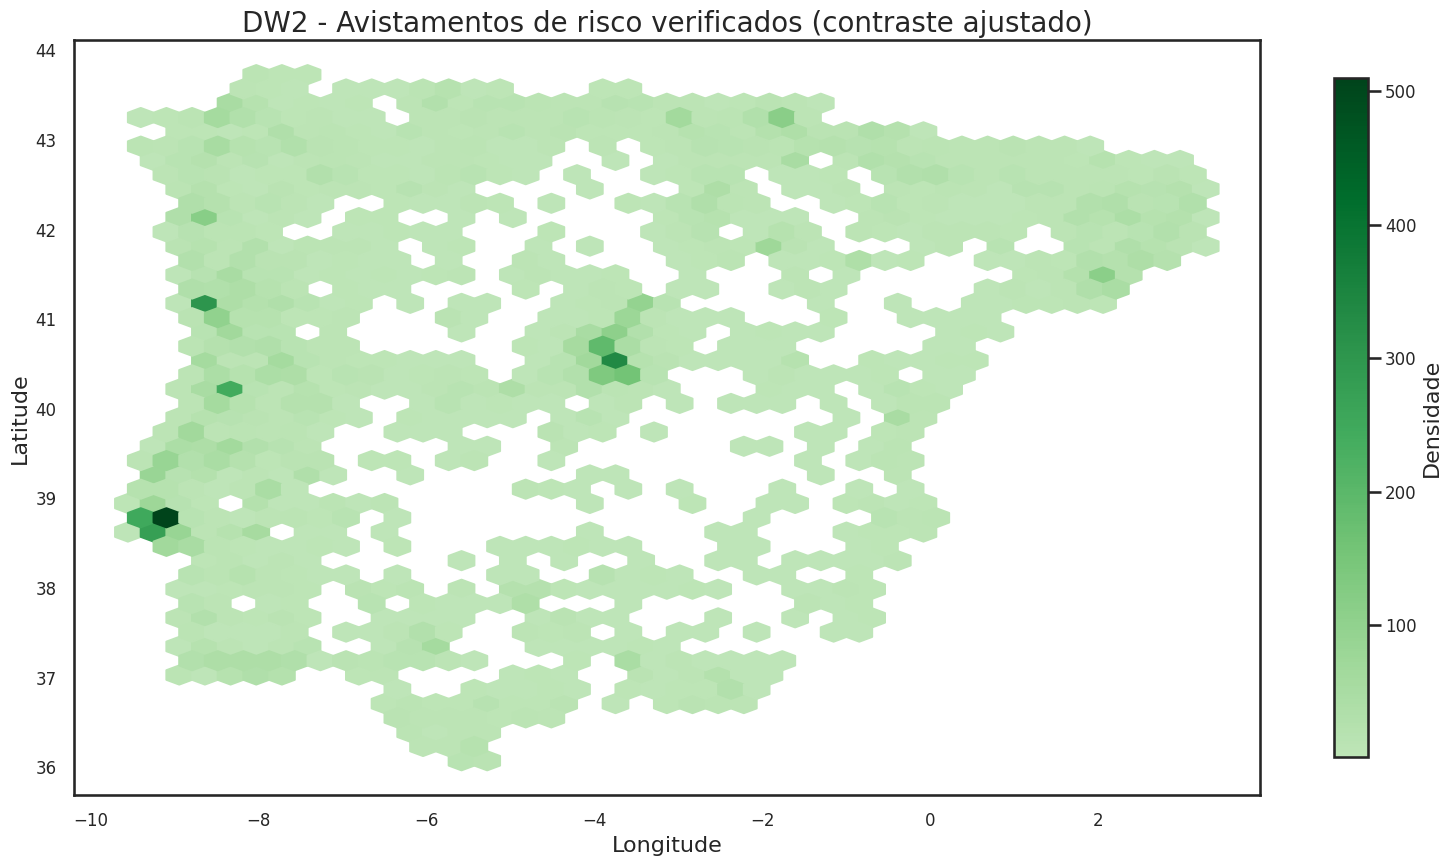

In [42]:
# DW2 (ajuste de contraste): tom minimo mais escuro
from matplotlib.colors import LinearSegmentedColormap

if "mock_geo" in globals():
    dw2_adj = mock_geo[(mock_geo["risk_type"] == "poisonous") & (mock_geo["verified"])].copy()
else:
    temp = df.copy()
    if "quality_grade" in temp.columns:
        temp["verified"] = temp["quality_grade"].astype(str).str.lower().eq("research")
    else:
        temp["verified"] = True
    if "risk_type" not in temp.columns:
        temp["risk_type"] = "poisonous"
    dw2_adj = temp.dropna(subset=["latitude", "longitude"]).copy()
    dw2_adj = dw2_adj[(dw2_adj["risk_type"] == "poisonous") & (dw2_adj["verified"])].copy()

if len(dw2_adj) > 0:
    base = plt.get_cmap("Greens")
    # Remove os tons muito claros do inicio da paleta
    darker_greens = LinearSegmentedColormap.from_list(
        "darker_greens",
        base(np.linspace(0.28, 1.0, 256))
    )

    fig, ax = plt.subplots(figsize=(16, 9))
    hb = ax.hexbin(
        dw2_adj["longitude"],
        dw2_adj["latitude"],
        gridsize=42,
        cmap=darker_greens,
        mincnt=1,
    )
    cbar = fig.colorbar(hb, ax=ax, shrink=0.9)
    cbar.set_label("Densidade")
    ax.set_title("DW2 - Avistamentos de risco verificados (contraste ajustado)")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(False)
    plt.tight_layout()

    # Sobrescreve o PNG do DW2 exportado anteriormente
    out = Path("tableau_exports/mockup_figs/DW2_mapa_risco_verificado.png")
    out.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out, dpi=320, bbox_inches="tight", facecolor="white")
    print(f"DW2 atualizado em: {out}")

    plt.show()
else:
    print("Sem pontos suficientes para DW2.")